# Notebook 02 — The Single-Cutoff Trap

**Claim:** Prophet wins RMSE on all three datasets with a standard 80/20 split.

**Reveal:** Shift the cutoff by 5% and rankings change on two out of three datasets.
One cutoff tells you almost nothing about generalisation.

In [1]:
import json
import logging
import warnings
from pathlib import Path

logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100})

FIGURES_DIR = Path("outputs/figures")
RESULTS_DIR = Path("outputs/results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig: plt.Figure, name: str) -> None:
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=120)
    print(f"Saved figure → {path}")


def save_json(data, name: str) -> None:
    path = RESULTS_DIR / name
    if isinstance(data, pd.DataFrame):
        payload = data.to_dict(orient="records")
    else:
        payload = data
    path.write_text(json.dumps(payload, indent=2, default=str))
    print(f"Saved results → {path}")


print("Ready.")


Ready.


In [2]:
from src.datasets.loader import load_airline, load_electricity, load_retail_base
from src.datasets.injector import inject_anomalies, ANOMALY_EVENTS

airline     = load_airline()
electricity = load_electricity()
retail_base = load_retail_base()
retail      = inject_anomalies(retail_base)

for name, s in [("Airline", airline), ("Electricity", electricity), ("Retail", retail)]:
    print(f"{name:15s}  {len(s):4d} pts  "
          f"{s.index[0].date()} → {s.index[-1].date()}  mean={s.mean():.1f}")


Airline           144 pts  1949-01-01 → 1960-12-01  mean=280.3
Electricity       397 pts  1990-01-01 → 2023-01-01  mean=132.1
Retail            208 pts  2020-01-06 → 2023-12-25  mean=545.6


In [3]:
from src.models.naive import SeasonalNaive
from src.models.arima import ARIMAModel
from src.models.prophet_model import ProphetModel
from src.models.xgboost_model import XGBoostModel
from src.models.lstm_model import LSTMModel

# LSTM uses reduced config for notebook speed; set INCLUDE_LSTM=True to enable
INCLUDE_LSTM = False


def make_factories(period: int = 12) -> dict:
    # Period-aware lag sets: monthly captures 2-year cycle; weekly captures annual (52w)
    if period == 52:
        lags = [1, 2, 3, 4, 13, 26]   # no lag-52: needs 52+ train pts, starves early cutoffs
        rolling = [4, 13, 26]
        arima_seasonal = (0, 0, 0, 0)  # seasonal ARIMA with period=52 is prohibitively slow
    else:
        lags = [1, 2, 3, 6, 12, 24]
        rolling = [3, 6, 12]
        arima_seasonal = (1, 1, 1, period)

    factories = {
        "Naive":   lambda: SeasonalNaive(period=period),
        "ARIMA":   lambda: ARIMAModel(order=(1, 1, 1), seasonal_order=arima_seasonal),
        "Prophet": ProphetModel,
        "XGBoost": lambda: XGBoostModel(n_estimators=100, max_depth=3,
                                         learning_rate=0.05, subsample=0.8,
                                         lags=lags, rolling_windows=rolling),
    }
    if INCLUDE_LSTM:
        factories["LSTM"] = lambda: LSTMModel(hidden_size=16, num_layers=2, epochs=20,
                                               seq_len=period)
    return factories


DATASETS = {
    "Airline":     (airline,     12),
    "Electricity": (electricity, 12),
    "Retail":      (retail,      52),
}


Importing plotly failed. Interactive plots will not work.


## Protocol A — 80 % cutoff

Train on the first 80 % of each series, evaluate on the last 20 %.

In [4]:
from src.evaluation.comparison import single_cutoff_eval

records_80 = []
for ds_name, (series, period) in DATASETS.items():
    for model_name, factory in make_factories(period).items():
        metrics = single_cutoff_eval(series, factory, cutoff_ratio=0.8)
        records_80.append({"Dataset": ds_name, "Model": model_name,
                           "RMSE": round(metrics["rmse"], 2),
                           "MAE":  round(metrics["mae"],  2)})
        print(f"  {ds_name:12s} {model_name:10s}  RMSE={metrics['rmse']:.2f}")

df_80 = pd.DataFrame(records_80)
save_json(df_80, "02_protocol_a_80pct.json")


  Airline      Naive       RMSE=75.23


13:27:19 - cmdstanpy - INFO - Chain [1] start processing


13:27:20 - cmdstanpy - INFO - Chain [1] done processing


  Airline      ARIMA       RMSE=31.79
  Airline      Prophet     RMSE=41.33


  Airline      XGBoost     RMSE=75.75
  Electricity  Naive       RMSE=9.71


...

  Electricity  ARIMA       RMSE=3.20
  Electricity  Prophet     RMSE=3.35


13:27:21 - cmdstanpy - INFO - Chain [1] start processing


13:27:21 - cmdstanpy - INFO - Chain [1] done processing


  Electricity  XGBoost     RMSE=15.38
  Retail       Naive       RMSE=177.75
  Retail       ARIMA       RMSE=185.90
  Retail       Prophet     RMSE=176.08


  Retail       XGBoost     RMSE=179.91
Saved results → outputs/results/02_protocol_a_80pct.json


### RMSE leaderboard — 80 % cutoff

In [5]:
leaderboard_80 = (df_80.pivot(index="Model", columns="Dataset", values="RMSE")
                       .sort_values("Airline"))
leaderboard_80["Rank_Airline"]     = leaderboard_80["Airline"].rank().astype(int)
leaderboard_80["Rank_Electricity"] = leaderboard_80["Electricity"].rank().astype(int)
leaderboard_80["Rank_Retail"]      = leaderboard_80["Retail"].rank().astype(int)
leaderboard_80


Dataset,Airline,Electricity,Retail,Rank_Airline,Rank_Electricity,Rank_Retail
Model,,,,,,
ARIMA,31.79,3.20,185.90,1,1,4
Prophet,41.33,3.35,176.08,2,2,1
Naive,75.23,9.71,177.75,3,3,2
XGBoost,75.75,15.38,179.91,4,4,3


## Now shift the cutoff to 75 %

Same models, same datasets, just 5 % earlier split.
If RMSE is a stable signal, rankings should be the same.

In [6]:
records_75 = []
for ds_name, (series, period) in DATASETS.items():
    for model_name, factory in make_factories(period).items():
        metrics = single_cutoff_eval(series, factory, cutoff_ratio=0.75)
        records_75.append({"Dataset": ds_name, "Model": model_name,
                           "RMSE": round(metrics["rmse"], 2),
                           "MAE":  round(metrics["mae"],  2)})

df_75 = pd.DataFrame(records_75)
save_json(df_75, "02_protocol_a_75pct.json")


13:27:22 - cmdstanpy - INFO - Chain [1] start processing


13:27:22 - cmdstanpy - INFO - Chain [1] done processing


13:27:23 - cmdstanpy - INFO - Chain [1] start processing


13:27:23 - cmdstanpy - INFO - Chain [1] done processing


13:27:25 - cmdstanpy - INFO - Chain [1] start processing


13:27:25 - cmdstanpy - INFO - Chain [1] done processing


Saved results → outputs/results/02_protocol_a_75pct.json


### RMSE leaderboard — 75 % cutoff

In [7]:
leaderboard_75 = (df_75.pivot(index="Model", columns="Dataset", values="RMSE")
                       .sort_values("Airline"))
leaderboard_75["Rank_Airline"]     = leaderboard_75["Airline"].rank().astype(int)
leaderboard_75["Rank_Electricity"] = leaderboard_75["Electricity"].rank().astype(int)
leaderboard_75["Rank_Retail"]      = leaderboard_75["Retail"].rank().astype(int)
leaderboard_75


Dataset,Airline,Electricity,Retail,Rank_Airline,Rank_Electricity,Rank_Retail
Model,,,,,,
ARIMA,23.01,4.02,167.94,1,2,4
Prophet,44.85,3.19,160.25,2,1,1
XGBoost,62.97,19.29,163.21,3,4,3
Naive,73.61,13.69,160.49,4,3,2


## Rank change (80 % → 75 %)

In [8]:
rank_cols = ["Rank_Airline", "Rank_Electricity", "Rank_Retail"]
rank_change = leaderboard_75[rank_cols] - leaderboard_80[rank_cols]
rank_change.columns = ["ΔRank Airline", "ΔRank Electricity", "ΔRank Retail"]
save_json(rank_change.reset_index(), "02_rank_changes.json")
rank_change.style.map(lambda v: "color: red"   if v > 0 else
                                "color: green"  if v < 0 else
                                "color: grey")


Saved results → outputs/results/02_rank_changes.json


,ΔRank Airline,ΔRank Electricity,ΔRank Retail
Model,,,
ARIMA,0,1,0
Naive,1,0,0
Prophet,0,-1,0
XGBoost,-1,0,0


## Visualise: how RMSE changes with cutoff position

13:27:26 - cmdstanpy - INFO - Chain [1] start processing


13:27:26 - cmdstanpy - INFO - Chain [1] done processing


13:27:27 - cmdstanpy - INFO - Chain [1] start processing


13:27:27 - cmdstanpy - INFO - Chain [1] done processing


13:27:28 - cmdstanpy - INFO - Chain [1] start processing


...

13:27:32 - cmdstanpy - INFO - Chain [1] start processing


13:27:32 - cmdstanpy - INFO - Chain [1] done processing


13:27:32 - cmdstanpy - INFO - Chain [1] start processing


13:27:32 - cmdstanpy - INFO - Chain [1] done processing


Saved figure → outputs/figures/02_rmse_vs_cutoff.png
Saved results → outputs/results/02_rmse_vs_cutoff.json


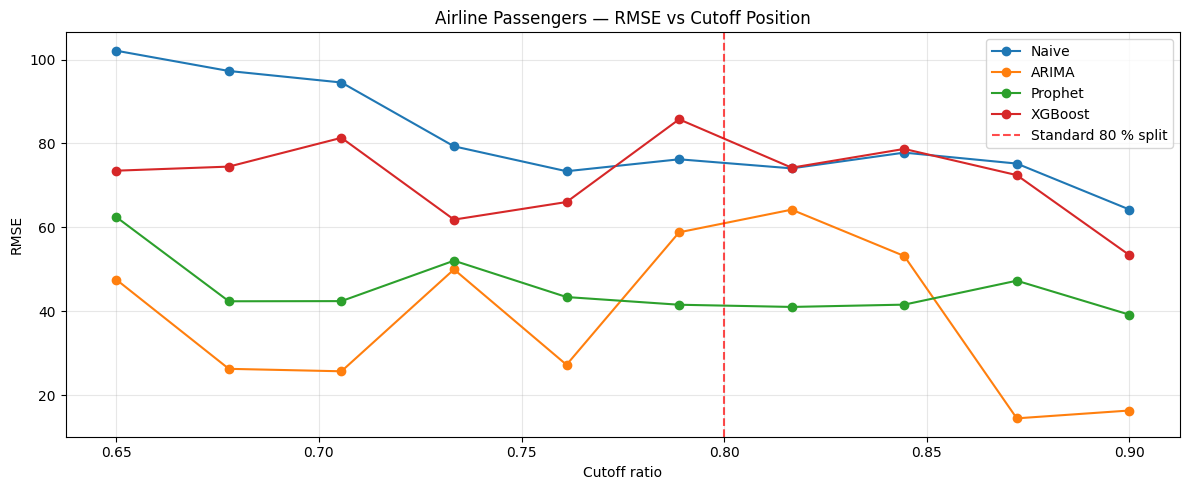

In [9]:
cutoff_ratios = np.linspace(0.65, 0.9, 10)
rmse_traces = {name: [] for name in make_factories(12)}

series, period = DATASETS["Airline"]
for ratio in cutoff_ratios:
    for model_name, factory in make_factories(period).items():
        m = single_cutoff_eval(series, factory, cutoff_ratio=ratio)
        rmse_traces[model_name].append(m["rmse"])

fig, ax = plt.subplots(figsize=(12, 5))
for model_name, values in rmse_traces.items():
    ax.plot(cutoff_ratios, values, marker="o", label=model_name)
ax.axvline(0.8, color="red", linestyle="--", alpha=0.7, label="Standard 80 % split")
ax.set_xlabel("Cutoff ratio")
ax.set_ylabel("RMSE")
ax.set_title("Airline Passengers — RMSE vs Cutoff Position")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "02_rmse_vs_cutoff.png")
save_json(
    [{"model": m, "cutoff_ratio": float(r), "rmse": v}
     for m, vals in rmse_traces.items()
     for r, v in zip(cutoff_ratios, vals)],
    "02_rmse_vs_cutoff.json",
)
plt.show()


## Conclusion

A single cutoff captures one specific temporal regime (one summer, one recession, one promotional period). The model that wins at 80 % may not win at 75 % or 85 %.

**The fix:** evaluate over many cutoffs with an expanding window — Protocol B. That is the subject of the next notebook.